# Q1. Metropolis MCMC

For this question, we implement the Metropolis-Hastings (MH) algorithm (an MCMC method) to perform Bayesian parameter estimation for a linear model. Rather than utilizing a frequentist optimization to find a single "best-fit" point, the MH algorithm allows us to sample the entire posterior distribution. By proposing random steps in the parameter space $[m, b]$ and accepting them based on their likelihood relative to the data, we generate a chain of samples whose density represents our degree of belief in specific parameter values. This approach is particularly powerful for characterizing uncertainties.

The model I choose is a linear model relating u-g to g-r  
The likelihood I define reduces to a negative log-likelihood equal to least-squares since I assume the error bars to be Gaussian and homoscedastic  
The assumptions I am making:  
- Assume Gaussian error bars  
- Assume error bars are homoscedastic  
- Assume data points are independent  
- Assume we ignore the outliers mentionned previously  



In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

## Load data

In [7]:
# Load light curve data from FITS files
# Change path to the directory containing the FITS files on your computer
path = Path("C:\\Users\\natha\\Downloads\\Lightcurve Data")

# Initialize a list to hold the data from all files
all_data = []

# Loop over all FITS files in the directory
for fits_file in path.glob("*.fits"):

    bands = {} # Dictionary to hold the data from this file
    
    with fits.open(fits_file) as hdul:
        # data type: ndarray of many ndarray of 3 float64
        data_uband = hdul[1].data
        data_gband = hdul[2].data
        data_rband = hdul[3].data
        data_iband = hdul[4].data
        data_zband = hdul[5].data
        data_yband = hdul[6].data
    
# Make 3 ndarray of float64 (time, mag, mag_error) for each band
    # uband
    time_uband = data_uband[:, 0]
    mag_uband = data_uband[:, 1]
    mag_error_uband = data_uband[:, 2]

    # gband
    time_gband = data_gband[:, 0]
    mag_gband = data_gband[:, 1]
    mag_error_gband = data_gband[:, 2]

    # rband
    time_rband = data_rband[:, 0]
    mag_rband = data_rband[:, 1]
    mag_error_rband = data_rband[:, 2]

    # iband
    time_iband = data_iband[:, 0]
    mag_iband = data_iband[:, 1]
    mag_error_iband = data_iband[:, 2]

    # zband
    time_zband = data_zband[:, 0]
    mag_zband = data_zband[:, 1]
    mag_error_zband = data_zband[:, 2]

    # yband
    time_yband = data_yband[:, 0]
    mag_yband = data_yband[:, 1]
    mag_error_yband = data_yband[:, 2]

# Add time, mag, mag_error to dictionary for each band
    u = {
        'time': time_uband,
        'mag': mag_uband,
        'mag_error': mag_error_uband
    }

    g = {
        'time': time_gband,
        'mag': mag_gband,
        'mag_error': mag_error_gband
    }

    r = {
        'time': time_rband,
        'mag': mag_rband,
        'mag_error': mag_error_rband
    }
    
    i = {
        'time': time_iband,
        'mag': mag_iband,
        'mag_error': mag_error_iband
    }

    z = {
        'time': time_zband,
        'mag': mag_zband,
        'mag_error': mag_error_zband
    }

    y = {
        'time': time_yband,
        'mag': mag_yband,
        'mag_error': mag_error_yband
    }
    
# Add dictionary for each band in a master dictionary for this file
    bands = {
        'u': u,
        'g': g,
        'r': r,
        'i': i,
        'z': z,
        'y': y
    }

# Append the master dictionary for this file to the master list
    all_data.append(bands)
    # print(f"Loaded file: {fits_file.name}")

#### Extracting data to which we will apply different algorithms

In [9]:
# Get mean magnitudes for u, g, r bands
u = np.array([np.mean(d["u"]['mag']) for d in all_data])
g = np.array([np.mean(d["g"]['mag']) for d in all_data])
r = np.array([np.mean(d["r"]['mag']) for d in all_data])

# Get mean u-band mag minus mean g-band mag, mean g-band mag minus mean r-band mag
u_minus_g = u - g
g_minus_r = g - r

#### Formatting data to which we will apply different algorithms

In the two graphs below (in section "Plotting data to which we will apply different algorithms"), we see that there are a few outliers. Since I have not taken a cosmology class, I do not know if this follows the normal behavior for quasars. Therefore, I make a data set for u-g vs. g-r with and without those outliers. For question 4, it makes a significant different in how the algorithms apply to the data.

##### Without outliers

In [13]:
# Remove outliers
mask = u_minus_g > -5

# Format clean u-g, g-r data in an array for density estimation and clustering algorithms
clean_data_array = np.column_stack((u_minus_g[mask], g_minus_r[mask]))

##### With outliers

In [15]:
# Format u-g, g-r data in an array for density estimation and clustering algorithms
data_array = np.column_stack((u_minus_g, g_minus_r))

#### Plotting data to which we will apply different algorithms

##### Without outliers

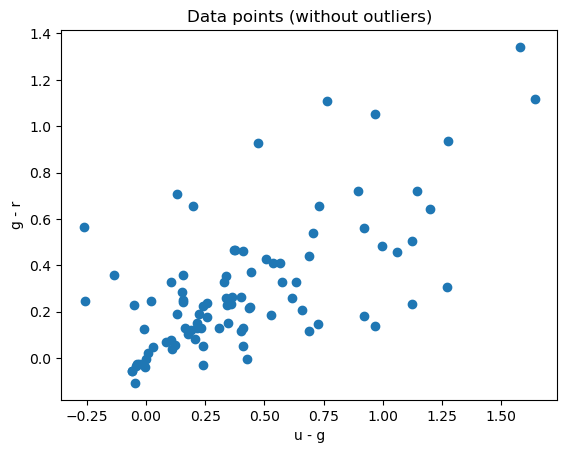

In [18]:
# Plot u-g vs g-r
plt.scatter(clean_data_array[:, 0], 
            clean_data_array[:, 1])

plt.xlabel('u - g')
plt.ylabel('g - r')
plt.title('Data points (without outliers)')
plt.show()

##### With outliers

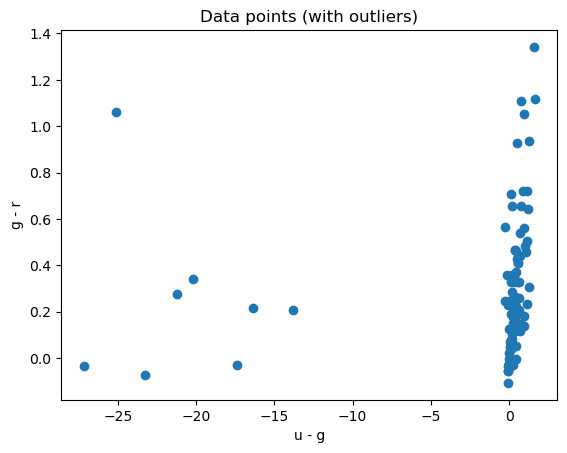

In [20]:
# Plot u-g vs g-r
plt.scatter(data_array[:, 0],
            data_array[:, 1])

plt.xlabel('u - g')
plt.ylabel('g - r')
plt.title('Data points (with outliers)')
plt.show()

## a) Metropolis MCMC

#### Write your own basic Metropolis MCMC algorithm (i.e., without using a MCMC software package). Make sure your code outputs diagnostic plots (such as the trace), because you will need to diagnose issues when you try to actually use it to perform Bayesian inference.

In [23]:
def metropolis_hastings(target_pdf, initial_state, num_samples, proposal_std):
    """   
    Parameters:
    - target_pdf: A function evaluating the target density P(x)
    - initial_state: The starting point for the Markov chain
    - num_samples: The number of samples to generate
    - proposal_std: The standard deviation for the proposal distribution
    """
    
    # ---------------------------------------------------------
    # STEP 1: INITIALIZATION
    # ---------------------------------------------------------
    # Create an array to store the chain of samples
    samples = np.zeros((num_samples, 2))
    
    # Set the starting state
    current_state = initial_state
    samples[0] = current_state
    
    # ---------------------------------------------------------
    # STEP 2: THE MCMC LOOP
    # ---------------------------------------------------------
    accepted_count = 0
    for i in range(1, num_samples):
        
        # A. Propose a candidate state
        # Draw a candidate from the proposal distribution Q(x' | x).
        # Here, we use a symmetric Gaussian centered on the current state.
        candidate_m = np.random.normal(loc=current_state[0], scale=proposal_std[0])
        candidate_b = np.random.normal(loc=current_state[1], scale=proposal_std[1])
        candidate_state = [candidate_m, candidate_b]
        
        # B. Calculate the acceptance probability
        # Evaluate the target density for both states.
        p_current = target_pdf(current_state)
        p_candidate = target_pdf(candidate_state)
        
        # Calculate the acceptance ratio (alpha). 
        # Note: Because our Gaussian proposal distribution is symmetric 
        # (meaning the probability of moving A->B is the same as B->A), 
        # the proposal terms cancel out of the standard MH equation.
        if p_current > 0:
            acceptance_ratio = p_candidate / p_current
        else:
            # Fallback in case the initial state had zero probability
            acceptance_ratio = 1.0 
            
        # C. Accept or reject
        # Draw a random uniform number between 0 and 1
        u = np.random.uniform(0, 1)
        
        # We accept if our random number is less than or equal to the ratio.
        if u <= acceptance_ratio:
            # ACCEPT: The candidate becomes our new current state
            current_state = candidate_state
            accepted_count += 1  # <--- Increment on success
        else:
            # REJECT: We remain at the previous state
            pass 
            
        # D. Save the state
        # Regardless of acceptance or rejection, record the current state.
        # (If rejected, we are recording a duplicate of the previous step).
        samples[i] = current_state

    # Calculate the final rate
    acceptance_rate = accepted_count / num_samples
    print(f"Acceptance Rate: {acceptance_rate:.2%}")


    # Plot posterior (validation)
    plt.scatter(samples[:, 0], samples[:, 1], alpha=1, s=0.8)
    plt.xlabel('Slope (m)')
    plt.ylabel('Intercept (b)')
    plt.title('Posterior')
    plt.show()

    # Plot traces (validation)
    fig, ax = plt.subplots(2, 1)
    ax[0].plot(samples[:, 0], linewidth=0.5) # Trace for m
    ax[0].set_title('Slope Trace')
    ax[1].plot(samples[:, 1], linewidth=0.5) # Trace for b
    ax[1].set_title('Intercept Trace')
    plt.show()
        
    return samples

## b) Best-Fit (HW1 Q1)

#### Best fit from Homework 1 Question 1 using a Frequentist approach with MLE

In [26]:
from scipy.optimize import minimize

# Have data
x = clean_data_array[:, 0]
y = clean_data_array[:, 1]
# Assume error bars to be homoscedastic: use least-squares

# Define a model
# The model I assume for the data is a linear model, y = mx + b

# Define the negative log-likelihood
# It is equal to least-squres since I assume errors are gaussian, homoscedastic
def negative_log_likelihood(theta, x, y):
    m, b = theta
    y_model = m * x + b
    least_squares = np.sum(((y - y_model)) ** 2)
    return least_squares

In [27]:
# Run MLE algorithm
# Initial guess for slope m and y-intercept b 
initial_guess = [0, 0]

# Perform fit with the "minimize" optimizer (minimize -log(L))
result = minimize(negative_log_likelihood, initial_guess, args=(x, y))

Slope: 0.47
Intercept: 0.10


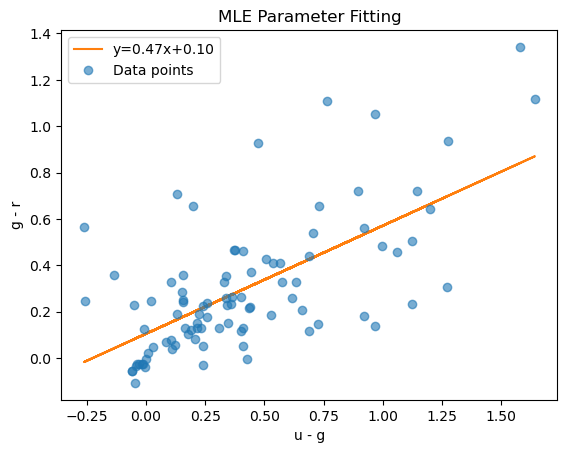

In [28]:
# Extract the fitted m and b values
m_fitted_mle = result.x[0]
b_fitted_mle = result.x[1]

print(f"Slope: {m_fitted_mle:.2f}")
print(f"Intercept: {b_fitted_mle:.2f}")

# Plot the result of the fit
plt.errorbar(x,
             y,
             # yerr=y_err,
             fmt='o',
             label='Data points',
             alpha=0.6)

plt.plot(x,
         m_fitted_mle * x + b_fitted_mle,
         label=f'y={m_fitted_mle:.2f}x+{b_fitted_mle:.2f}')

plt.xlabel('u - g')
plt.ylabel('g - r')
plt.title('MLE Parameter Fitting')
plt.legend()
plt.show()

#### Best fit from Homework 1 Question 1 using a Bayesian approach with Metropolis MCMC

In [30]:
# Have data
x = clean_data_array[:, 0]
y = clean_data_array[:, 1]
# Assume error bars to be homoscedastic: use least-squares

# Define a model
# The model I assume for the data is a linear model, y = mx + b

# Define the negative log-likelihood
# It is equal to least-squres since I assume errors are gaussian, homoscedastic
def negative_log_likelihood(theta, x, y):
    m, b = theta
    y_model = m * x + b
    least_squares = np.sum(((y - y_model)) ** 2)
    return least_squares

# Define a simple target distribution
def target_dist(theta):
    # We want to maximize this, so minimize the error
    error = negative_log_likelihood(theta, x, y)
    return np.exp(-0.5 * error)

Acceptance Rate: 35.08%


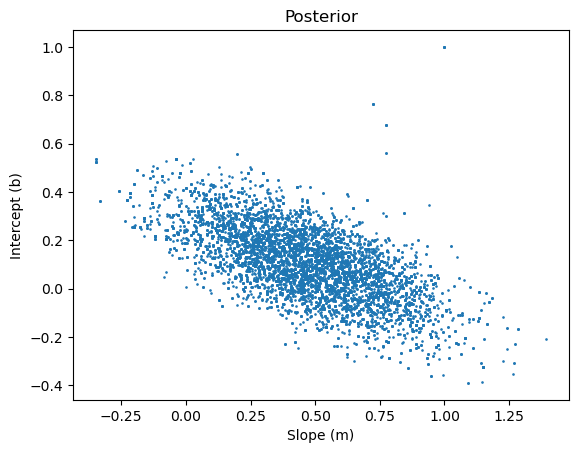

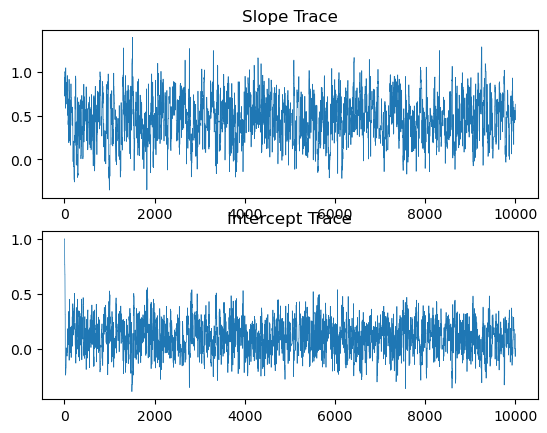

In [31]:
# Run Metropolis MCMC algorithm
chain = metropolis_hastings(
    target_pdf=target_dist,
    initial_state=[1.0,1.0], # Start far from the mean to see burn-in
    num_samples=10000, 
    proposal_std=[0.25,0.25]
)

$\textbf{Joint posterior distribution}$: The scatter plot of the accepted samples represents the joint posterior distribution of the slope ($m$) and intercept ($b$). This visualization provides a topographical map of the "probability mountain" defined by our model and data. The density of the points indicates the regions of highest probability, while the overall shape reveals the correlation between parameters. In linear regression, a diagonal orientation is common, showing how a change in the proposed slope requires a compensatory shift in the intercept to keep the model consistent with the observed data points.  

$\textbf{Slope Trace Plot}$: The slope trace plot monitors the value of $m$ over the course of 10,000 iterations. This is a primary diagnostic for convergence. The initial segment of the plot represents the "burn-in" period, where the algorithm migrates from its arbitrary starting point ($1.0, 1.0$) toward the high-probability region. The subsequent "fuzzy caterpillar" appearance indicates that the chain has reached a stationary distribution. The vertical width of these oscillations directly reflects the uncertainty from the marginal posterior of the slope; a well-mixed chain should show no long-term trends, only random-looking fluctuations around the mean.  

$\textbf{Intercept Trace Plot}$: Similarly, the intercept trace plot tracks the evolution of the parameter $b$. By observing this trace alongside the slope, we can verify that both parameters have successfully "burned-in" and are exploring the same region of the parameter space (in this case the burn-in is done very quickly). Once the burn-in period is discarded, the average of the remaining samples in this trace provides our final estimate for the intercept, while the standard deviation of those samples gives us the $1\sigma$ measurement error.

Slope: 0.47 ± 0.25
Intercept: 0.10 ± 0.14


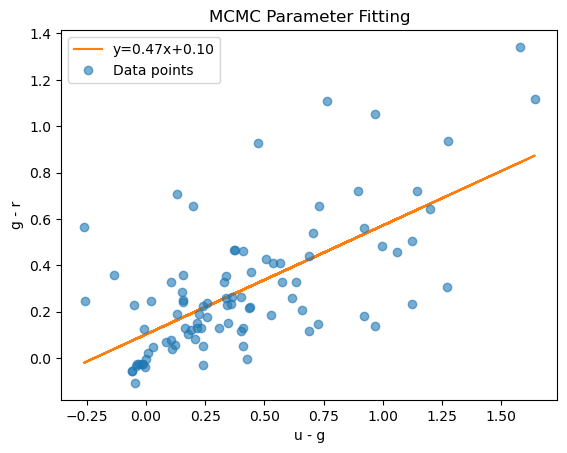

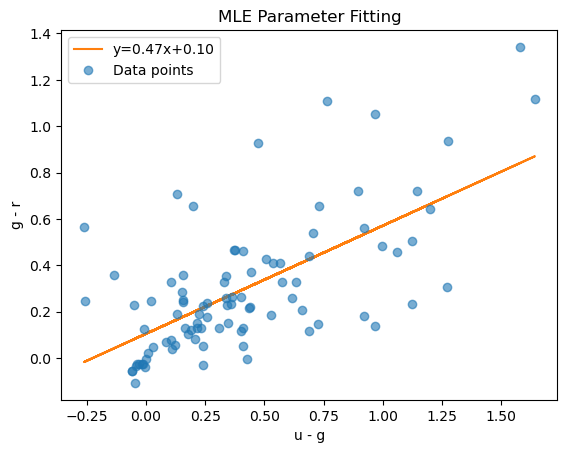

In [33]:
# 1. Look at the portion of the chains that is burned-in (i.e. mostly flat)
split_idx = int(len(chain) * 0.25)
burnedin_samples = chain[split_idx:] # Discard burn-in values (first 25%, to be safe)

# 2. Calculate the mean (the best fit)
m_fitted_mcmc = np.mean(burnedin_samples[:, 0])
b_fitted_mcmc = np.mean(burnedin_samples[:, 1])

# 3. Calculate the standard deviation (the uncertainty on the best fit)
m_err = np.std(burnedin_samples[:, 0])
b_err = np.std(burnedin_samples[:, 1])

print(f"Slope: {m_fitted_mcmc:.2f} ± {m_err:.2f}")
print(f"Intercept: {b_fitted_mcmc:.2f} ± {b_err:.2f}")

# 4. Plot the result of the fit (MCMC)
plt.errorbar(x,
             y,
             # yerr=y_err,
             fmt='o',
             label='Data points',
             alpha=0.6)

plt.plot(x,
         m_fitted_mcmc * x + b_fitted_mcmc,
         label=f'y={m_fitted_mcmc:.2f}x+{b_fitted_mcmc:.2f}')

plt.xlabel('u - g')
plt.ylabel('g - r')
plt.title('MCMC Parameter Fitting')
plt.legend()
plt.show()

# Plot the result of the fit (MLE)
plt.errorbar(x,
             y,
             # yerr=y_err,
             fmt='o',
             label='Data points',
             alpha=0.6)

plt.plot(x,
         m_fitted_mle * x + b_fitted_mle,
         label=f'y={m_fitted_mle:.2f}x+{b_fitted_mle:.2f}')

plt.xlabel('u - g')
plt.ylabel('g - r')
plt.title('MLE Parameter Fitting')
plt.legend()
plt.show()

We get the same result of parameter estimation using MLE and my Metropolis algorithm, as shown in the above graph

#### Plot the posteriors (e.g., in a corner plot)

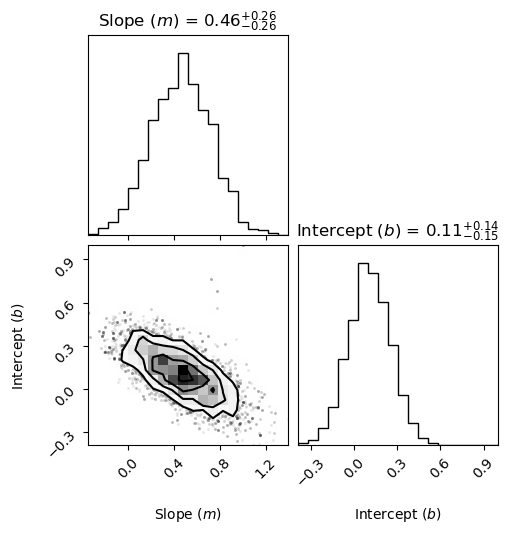

In [36]:
import corner

fig = corner.corner(
    chain,
    show_titles=True,
    labels=["Slope ($m$)", "Intercept ($b$)", "$Z$"]
);

#### Do you get the same result? Discuss the issues you ran into in this endeavour.

As we can see from the joint posterior for m and b, there is some amount of correlation between the two parameters. For a simple 2D linear model, standard Metropolis-Hastings is usually "good enough", even with correlation. However, as we move toward complex models with more parameters, the "curse of dimensionality" makes standard MH nearly impossible to tune. That is where Affine Invariant Ensemble Sampling becomes essential to efficiently map out the posterior.